# Lehtiö et al., 2021: Multimodal data integration

In modern -omics experiments, it is common to measure multiple _modalities_ at once. It is a central challenge to integrate these complementary measurements to a unified view of the biological state of the specimen. `alphapepttools` seamlessly integrates MS-proteomics data with other modalities via the shared `scverse` infrastructure. 

## Study background 

In this tutorial, we explore the integration of multiple modalities in a clinical setting by reanalysing the dataset by **Lehtiö et al., 2021**. In the original publication, the authors recorded a deep proteome of non-small cell lung cancer (NSCLC) samples from 141 patients with fractionated DDA-TMT proteomics. They identified 6 proteomic cancer subtypes and associated them with histological subtypes, immune infiltration, and clinical outcomes. Notably, they compared the proteomic subtypes post hoc with matched measurements of RNA microarray + methylation experiments from a previous publication. Here, we demonstrate how these matched -omics measurements can instead be jointly modelled in a MOFA+ analysis. 


## References

1. **Proteomics Data**: Lehtiö, J. et al. Proteogenomics of non-small cell lung cancer reveals molecular subtypes associated with specific therapeutic targets and immune-evasion mechanisms. Nat Cancer 2, 1224–1242 (2021). [PXD020191](https://www.ebi.ac.uk/pride/archive/projects/PXD020191)

2. **RNA microarray data** Karlsson, A. et al. Gene Expression Profiling of Large Cell Lung Cancer Links Transcriptional Phenotypes to the New Histological WHO 2015 Classification. J Thorac Oncol 12, 1257–1267 (2017).

3. **Methylation data** Karlsson, A. et al. Genome-wide DNA Methylation Analysis of Lung Carcinoma Reveals One Neuroendocrine and Four Adenocarcinoma Epitypes Associated with Patient Outcome. Clin Cancer Res 20, 6127–6140 (2014).

## Analysis

To run this tutorial, you need to install the scverse packages `decoupler`, `muon`, `mofapy2`, and `mofax` in your local environment

### Load packages

In [1]:
# Install the requirements file requirements/requirements-multimodal.txt in python 3.13
# pip install -r requirements/requirements-multimodal.txt

# The file was generated by running 
# ! pip install muon mofapy2 mofax decoupler jupyter alphapepttools

In [2]:
import alphapepttools as apt
import anndata as ad

import decoupler as dc
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

import mudata as md
import muon
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from alphabase.pg_reader.keys import PGCols
from sklearn.metrics import silhouette_score

/Users/lucas-diedrich/mamba/envs/at-paper-multimodal/lib/python3.13/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(
/Users/lucas-diedrich/mamba/envs/at-paper-multimodal/lib/python3.13/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [3]:
# Mirror the central alphapepttools plot settings (defaults.PlotSettings) onto matplotlib's
# global rcParams so notebook figures match the library defaults.
from alphapepttools.pl import defaults

_plot_config = defaults.plot_settings.to_dict()
plt.rcParams.update(
    {
        "font.size": _plot_config["font_sizes"]["medium"],
        "axes.titlesize": _plot_config["axes"]["title_size"],
        "axes.labelsize": _plot_config["axes"]["label_size"],
        "xtick.labelsize": _plot_config["axes"]["tick_size"],
        "ytick.labelsize": _plot_config["axes"]["tick_size"],
        "legend.fontsize": _plot_config["legend"]["font_size"],
        "legend.title_fontsize": _plot_config["legend"]["title_size"],
        "lines.linewidth": _plot_config["linewidths"]["medium"],
        "lines.markersize": _plot_config["marker_sizes"]["medium"],
        "figure.dpi": _plot_config["resolution"]["dpi"],
        "savefig.dpi": _plot_config["resolution"]["dpi"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

### Settings

In [4]:
N_FACTORS = 25

### Helper functions

We define a few helper functions that we will reuse in the rest of the tutorial:

In [5]:
def mvalue(adata: ad.AnnData, *, alpha: float = 0.01, layer: str | None = None, copy: bool = False) -> ad.AnnData:
    r"""Conversion of methylation beta values to M values

    .. math::

        M = \log_{2}{\frac{\beta + \alpha}{(1-\beta) + \alpha}}


    Parameters
    ----------
    adata
        AnnData object
    alpha
        Pseudocount added to the data to prevent infinite values
    layer
        Layer to act on. If `None`, uses adata.X
    copy
        If `True`, returns a copy of the anndata object, else modifies the object inplace

    References
    ----------
    - Du, P., Zhang, X., Huang, CC. et al.
    Comparison of Beta-value and M-value methods for quantifying methylation levels by microarray analysis.
    BMC Bioinformatics 11, 587 (2010). https://doi.org/10.1186/1471-2105-11-587
    - Ricard Argelaguet (GitHub): https://github.com/bioFAM/MOFA/issues/44

    """
    adata = adata.copy() if copy else adata
    data = adata.X if layer is None else adata.layers[layer]

    data = np.log2((data + alpha) / ((1 - data) + alpha))

    if layer is None:
        adata.X = data
    else:
        adata.layers[layer] = data

    return adata if copy else None

In [6]:
# Shared color scheme for the omics modalities, reused across loading and enrichment plots
palette = {"proteins": "#2b7bba", "rna": "#705eaa", "methylation": "#2c944c"}


def plot_modality_loadings(
    data: pd.DataFrame,
    *,
    score: str,
    feature: str,
    palette: dict,
    modality_column: str = "modality",
    xlabel: str = "Score",
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """Horizontal bar plot of per-feature scores, colored by omics modality.

    Used to display either MOFA+ factor loadings or gene set enrichment scores. Each
    bar corresponds to a single feature (a gene or a pathway) and is colored by the
    modality it originates from.

    Parameters
    ----------
    data
        Long-format dataframe with one row per feature.
    score
        Column holding the numeric value drawn as bar length (x-axis).
    feature
        Column holding the feature labels shown on the y-axis.
    palette
        Mapping of modality name to color.
    modality_column
        Column holding the modality of each feature.
    xlabel
        Label of the x-axis.
    ax
        Axes to draw on. If `None`, a new figure and axes are created.

    Notes
    -----
    Feature labels that occur more than once in `data` (e.g. a pathway or gene shared
    across modalities) are rendered in bold to highlight cross-modal agreement.
    """
    data = data.sort_values(by=score)
    colors = data[modality_column].map(palette)

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 8))

    ax.barh(range(len(data)), data[score], color=colors)
    ax.set_yticks(range(len(data)))
    labels = ax.set_yticklabels(data[feature], fontsize=8)

    # Highlight features that occur in more than one row (e.g. shared across modalities)
    feature_counts = data[feature].value_counts()
    for label, name in zip(labels, data[feature], strict=True):
        if feature_counts[name] > 1:
            label.set_fontweight("bold")
    ax.axvline(0, color="black", linewidth=0.8)  # zero reference line
    ax.set_xlabel(xlabel)

    # Legend mapping each color back to its modality
    handles = [mpatches.Patch(color=palette[modality], label=modality) for modality in data[modality_column].unique()]
    ax.legend(handles=handles, title="Modality", bbox_to_anchor=(1.01, 1), loc="upper left")

    ax.spines[["top", "right"]].set_visible(False)
    return ax

## Read and preprocess MS-proteomics data

We will first focus on the MS-proteomics data. We downloaded the gene-level aggregated data from the corresponding pride repository [PXD020191](https://www.ebi.ac.uk/pride/archive/projects/PXD020191).

### IO
In a first step, we will ingest and preprocess the MS-proteomics data separately from the other modalities. 

In [7]:
report_path = "../data/raw/dda-1/gene-symbols_table.txt"

column_mapping = {
    PGCols.GENES: "Protein accession",
    PGCols.DESCRIPTION: "Description",
    "protein_coverage": "Coverage",
    "n_proteins": "Amount Proteins",
    PGCols.PROTEINS: "Proteins in group",
}
measurement_regex = r"^set\d{2}_tmt10plex_\d{3}[NC]?$"

adata = apt.io.read_pg_table(
    report_path,
    # TODO: change to "custom"
    search_engine="diann",
    column_mapping=column_mapping,
    measurement_regex=measurement_regex,
)
adata

AnnData object with n_obs × n_vars = 170 × 14058
    var: 'description', 'protein_coverage', 'n_proteins', 'proteins'
    layers: None (.X)

We obtained 170 samples with a total of 14058 unique protein groups.

Now, we read the available clinical metadata, which was extracted from the [supplementary information](https://doi.org/10.1038/s43018-021-00259-9) of the original study. 

In [8]:
metadata = pd.read_csv("https://datashare.biochem.mpg.de/s/x5gMNoZnagZAonT/download", sep="\t", index_col="tmt_set_and_label")
metadata

,sample_id,proteome_subtype,age,sex,previous_histology,who2015_histology,ac_mrna_subtype_tcga,sqcc_mrna_subtype_tcga,nsclc_mrna_subtype_karlsson_et_al._2017,smokingstatus,...,zfhx3_mut,tmb,cancer_testis_antigens,ncps,purity,methylation_scores_overall,methylation_scores_promoter,methylationpresent,panelseqpresent,transcriptomicspresent
tmt_set_and_label,,,,,,,,,,,,,,,,,,,,,
set13_tmt10plex_129N,LU85,1,67.0,F,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,5.86458,0,8,0.30,0.491897,0.158030,True,True,True
set13_tmt10plex_128C,LU277,1,80.0,F,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,2.93229,2,5,0.25,0.525326,0.176840,True,True,True
set07_tmt10plex_126,LU376,1,72.0,M,AC,AC,Terminal respiratory unit,NaN,9.0,Never_smoker,...,0.0,2.93229,0,2,0.18,0.510334,0.170185,True,True,True
set11_tmt10plex_129C,LU1115,1,80.0,M,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,5.86458,4,5,0.31,0.505183,0.163569,True,True,True
set12_tmt10plex_128N,LU804,1,73.0,F,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,5.27812,1,7,0.38,0.533692,0.181161,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
set04_tmt10plex_128C,LU745,6,70.0,M,SqCC,SqCC,NaN,Classical,2.0,Former,...,0.0,8.79687,2,22,0.62,NaN,NaN,False,True,True
set14_tmt10plex_128C,LU1020,6,80.0,M,SqCC,SqCC,NaN,Classical,2.0,Former,...,0.0,24.04480,5,13,0.57,0.486081,0.154912,True,True,True
set06_tmt10plex_129C,LU372,6,69.0,M,SqCC,SqCC,NaN,Classical,2.0,Current,...,0.0,15.24790,9,27,0.68,0.437679,0.136954,True,True,True


We add the metadata to the anndata object with `alphapepttools.pp.add_metadata` and extract batch information (`tmt_plex`) from the TMT sample id. 

In [9]:
adata = apt.pp.add_metadata(adata, metadata, axis=0, keep_data_shape=False)
adata.obs = adata.obs.reset_index(names="tmt_sample_id").set_index("sample_id")
adata.obs["tmt_plex"] = adata.obs["tmt_sample_id"].str.extract("set([0-9]+)_")[0].tolist()
adata.obs["tmt_channel"] = adata.obs["tmt_sample_id"].str.extract("_([A-Za-z0-9]+)$")[0].tolist()
adata

AnnData object with n_obs × n_vars = 141 × 14058
    obs: 'tmt_sample_id', 'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'ac_mrna_subtype_tcga', 'sqcc_mrna_subtype_tcga', 'nsclc_mrna_subtype_karlsson_et_al._2017', 'smokingstatus', 'smokingstatus_binary', 'stage_general', 'stage_detailed', 'os_years', 'osbin', 'relapse_years', 'relapse_bin', 'adjuvant_therapy', 'pdl1_ihc', 'cd3_stromal_ihc', 'cd8_stromal_ihc', 'stroma_estimate', 'immune_estimate', 'arid1a_mut', 'arid2_mut', 'asxl1_mut', 'atm_mut', 'blm_mut', 'braf_mut', 'cdkn2a_mut', 'egfr_mut', 'fat1_mut', 'keap1_mut', 'kmt2c_mut', 'kmt2d_mut', 'kras_mut', 'nf1_mut', 'nfe2l2_mut', 'notch2_mut', 'pik3ca_mut', 'pold1_mut', 'pten_mut', 'rb1_mut', 'rbm10_mut', 'smarca4_mut', 'stk11_mut', 'tp53_mut', 'zfhx3_mut', 'tmb', 'cancer_testis_antigens', 'ncps', 'purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'methylationpresent', 'panelseqpresent', 'transcriptomicspresent', 'tmt_plex', 'tmt_chan

The study design included 16 rotating in-set references, and one full reference set (Set17). These samples were used for normalization and QC, but do not contain biological information (i.e. they are absent from the metadata table). They are removed by the `apt.pp.add_metadata` call, yielding 141 biological samples.

### Quality control + Preprocessing

To evaluate between-run variation, we check the missingness patterns of each batch. Note that we do not look at sample-level aggregates of intensity values as the data has already been transformed by the search engine (see methods of the original paper) and aggregated intensity values are difficult to interpret at this stage.

In [10]:
apt.metrics.fraction_complete(adata, axis="obs", column="fraction_complete_obs")
apt.metrics.fraction_complete(adata, axis="var", column="fraction_complete_var")

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_21109/1164706306.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


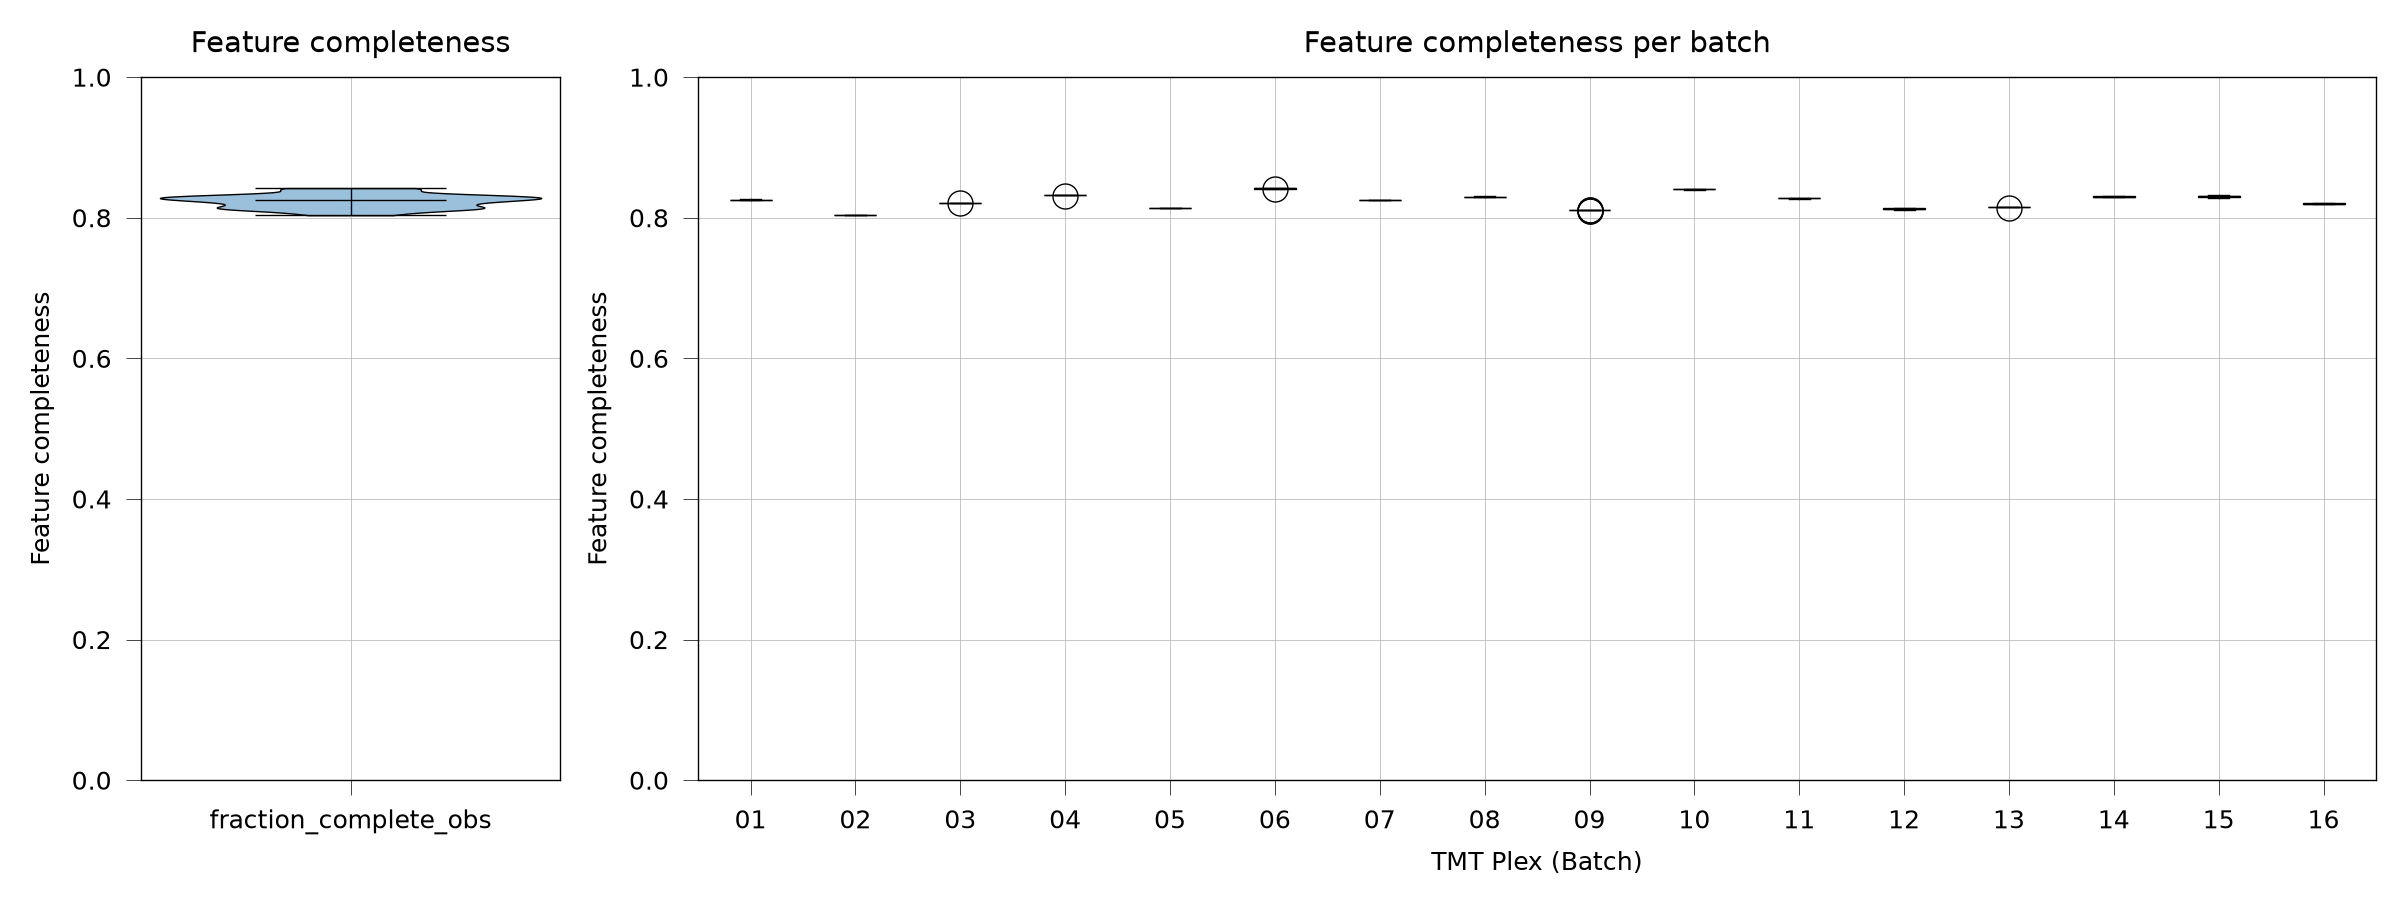

In [11]:
fig, axm = apt.pl.create_figure(1, 2, figsize=(8, 3), width_ratios=(1, 4))

apt.pl.violinplot(ax=axm[0], data=adata, direct_columns=["fraction_complete_obs"])
apt.pl.label_axes(ax=axm[0], xlabel=None, ylabel="Feature completeness", title="Feature completeness")
axm[0].set_ylim(0.0, 1.0)


apt.pl.boxplot(ax=axm[1], data=adata, grouping_column="tmt_plex", value_column="fraction_complete_obs")

apt.pl.label_axes(
    ax=axm[1], xlabel="TMT Plex (Batch)", ylabel="Feature completeness", title="Feature completeness per batch"
)
axm[1].set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()

We observe a low variability of the feature missingness between samples and between batches, indicating a good comparability of the samples between batches.

We also look at the feature-wise missingness: Most features are 100% complete, suggesting deep proteome profiling

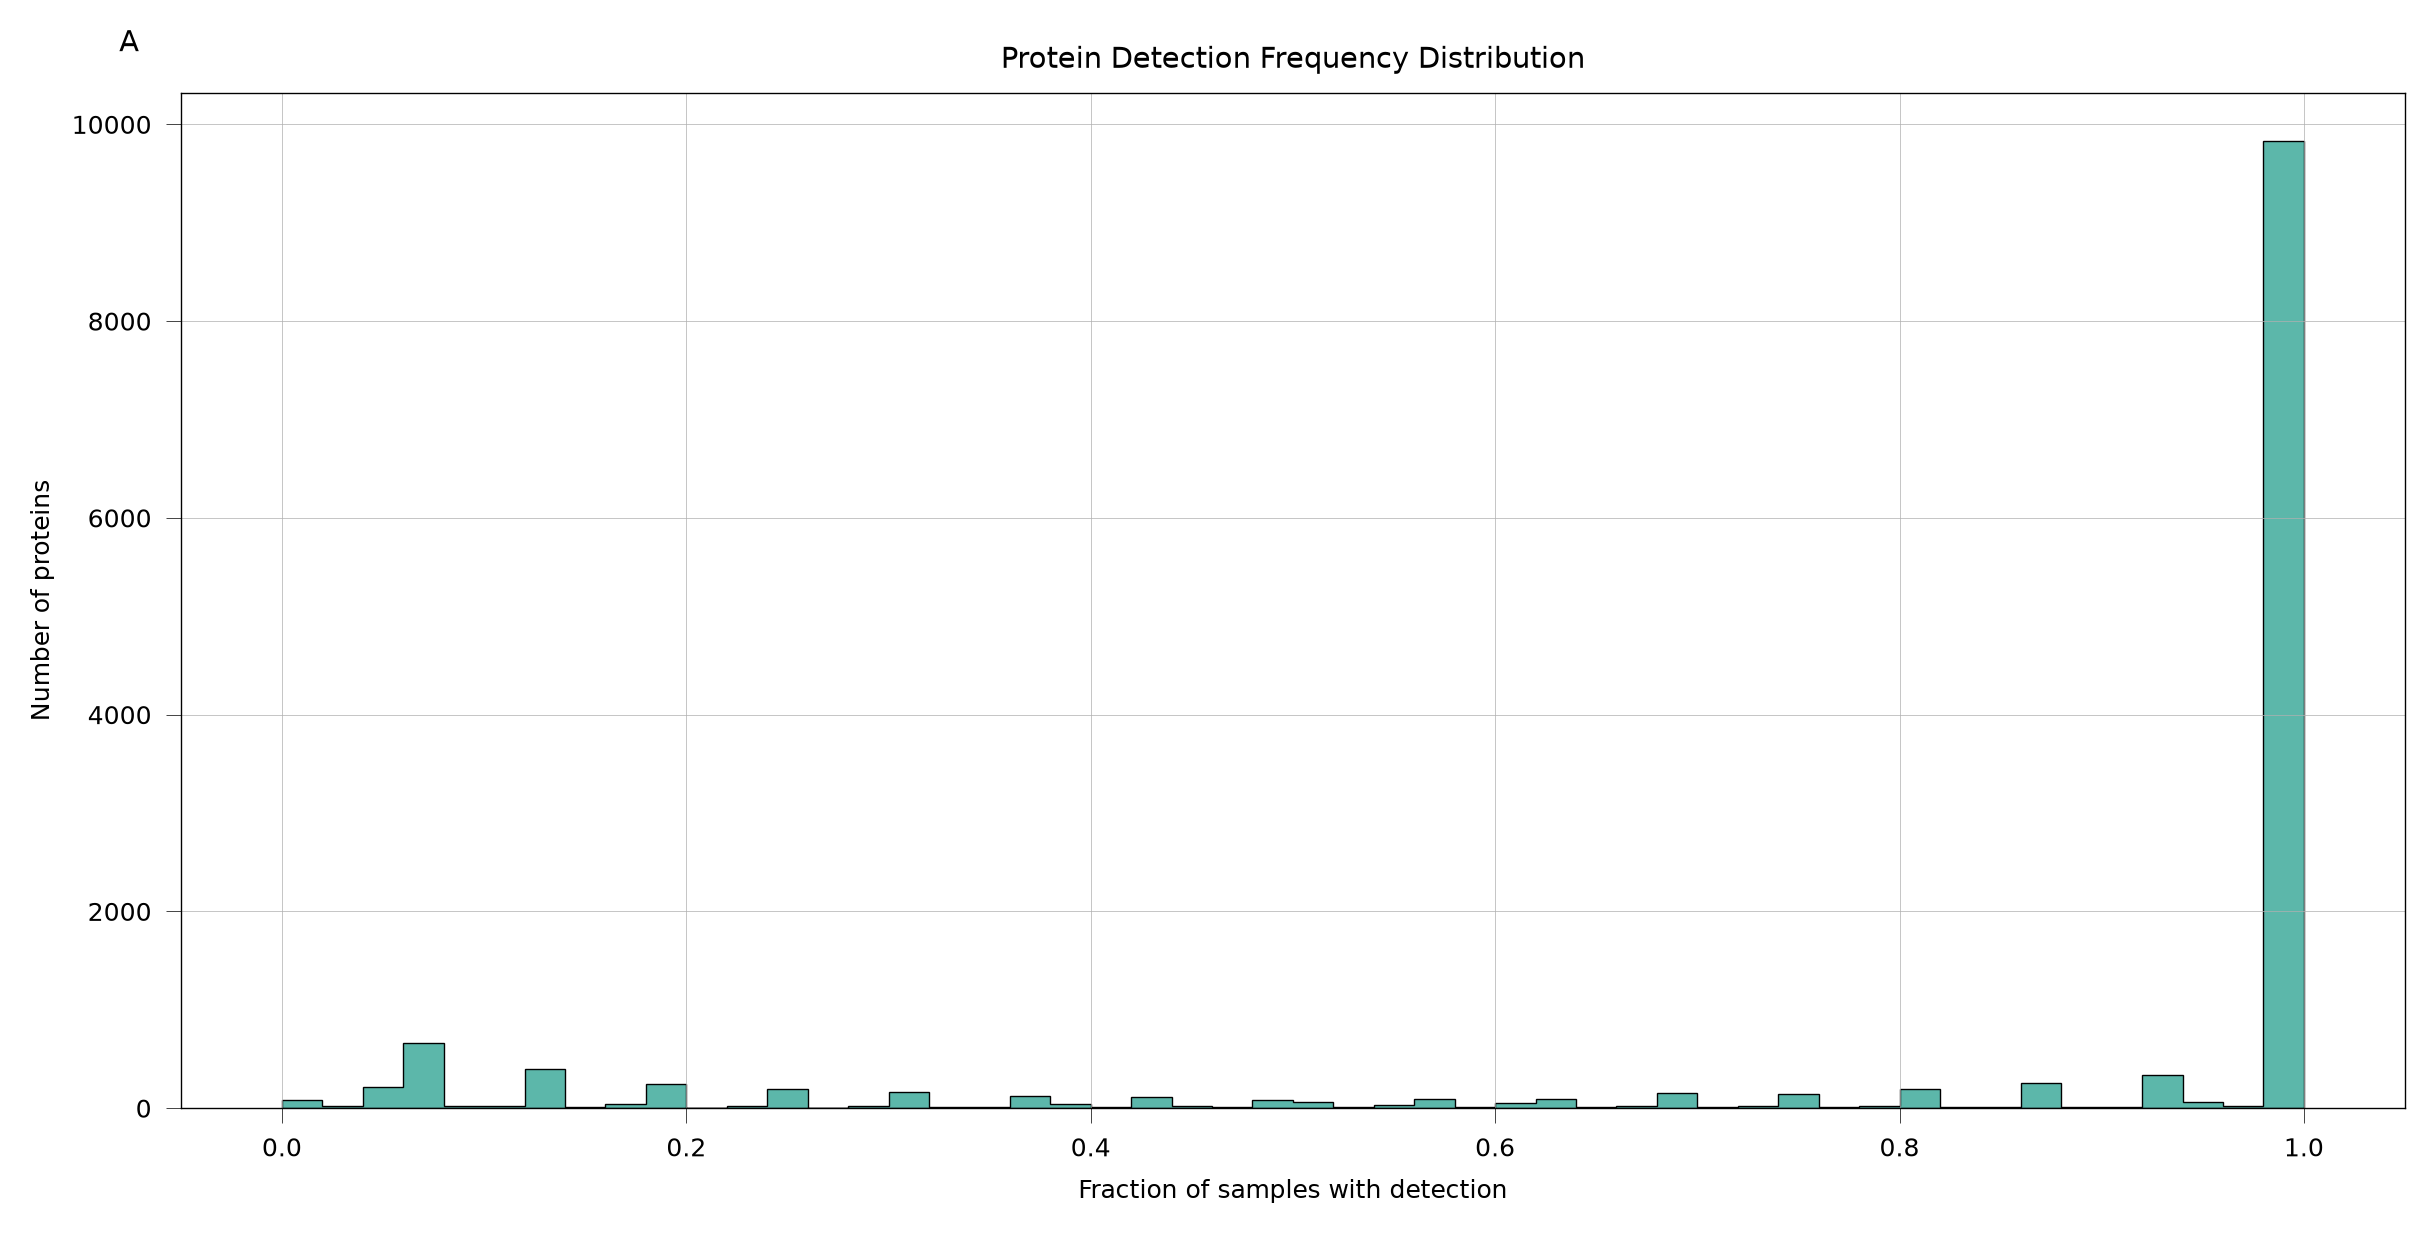

In [12]:
# Histogram of detection frequency combined with a rank plot
fig, axm = apt.pl.create_figure(1, 1, figsize=(8, 4))

# Histogram
ax = axm.next()
apt.pl.histogram(
    data=adata,
    value_column="fraction_complete_var",
    bins=50,
    ax=ax,
    color=apt.pl.BaseColors.get("green"),
    hist_kwargs={"histtype": "stepfilled", "edgecolor": "black"},
)

apt.pl.label_axes(
    ax,
    xlabel="Fraction of samples with detection",
    ylabel="Number of proteins",
    title="Protein Detection Frequency Distribution",
    enumeration="A",
)

Following the original study, we drop all incomplete features.

In [13]:
adata = apt.pp.filter_data_completeness(adata, max_missing_count=0, action="drop")

INFO:root:pp.filter_data_completeness(): drop 4265 / 14058 features with >0 missing values.


#### Transformation and centering

We follow the original preprocessing steps and perform log2-transformation with `alphapepttools.pp.nanlog` and median centering of the features. We store the intermediate results in separate layers of the anndata object.

In [14]:
adata.layers["raw"] = adata.X.copy()

In [15]:
apt.pp.nanlog(adata)
adata.layers["log2"] = adata.X.copy()

In [16]:
apt.pp.scale_and_center(adata, layer=None, center=True, scale=False, copy=False)
adata.layers["median_centered"] = adata.X.copy()

INFO:root:pp.scale_and_center(): Scaling data with standard scaler.


#### Visual inspection 
We check the data qualitatively and investigate whether histological subtypes separate, representing expected biological variation.

In [17]:
apt.tl.pca(adata)

INFO:alphapepttools.tl.embeddings:computing PCA


/Users/lucas-diedrich/mamba/envs/at-paper-multimodal/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/lucas-diedrich/mamba/envs/at-paper-multimodal/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_21109/3405118298.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


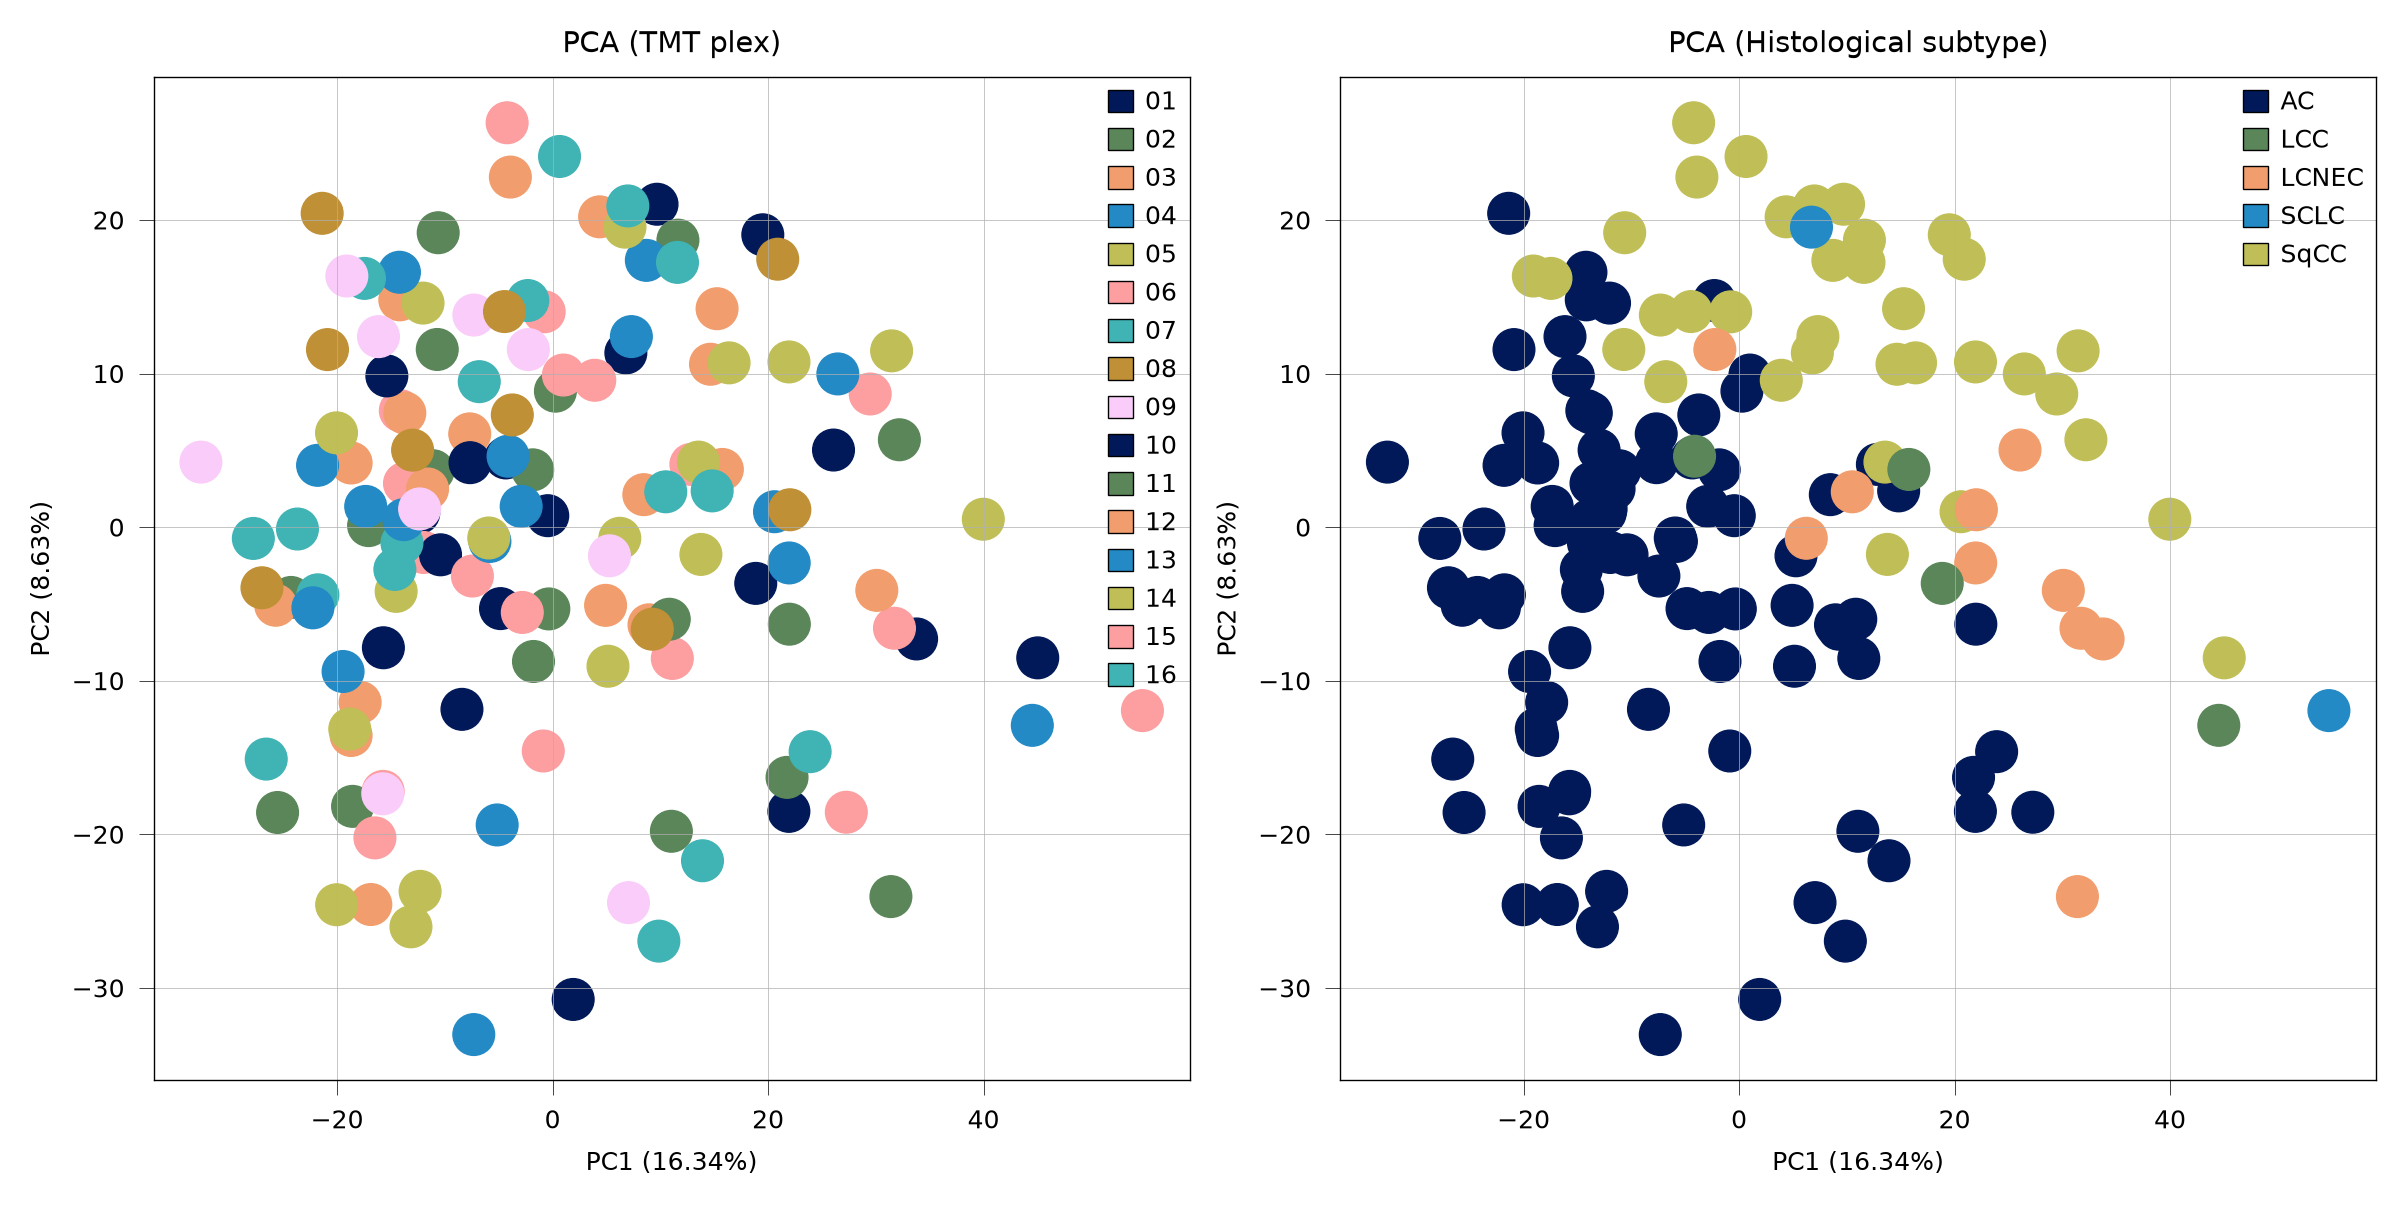

In [18]:
fig, axm = apt.pl.create_figure(1, 2, figsize=(8, 4))


apt.pl.plot_pca(adata, y_column=2, ax=axm[0], color_map_column="tmt_plex", legend="auto")
apt.pl.label_axes(ax=axm[0], title="PCA (TMT plex)")


apt.pl.plot_pca(adata, y_column=2, ax=axm[1], color_map_column="who2015_histology", legend="auto")
apt.pl.label_axes(ax=axm[1], title="PCA (Histological subtype)")

plt.tight_layout()

Indeed, as expected, the data separates based on histological subtypes and not TMT runs.

## Multimodal Analysis | Integrate with complementary modalities

In the original paper, the proteomics data was clustered and the proteomic phenotypes were associated post-hoc with complementary RNA and methylation microarray data. 

Here, we try to model these different modalities all at once with a MOFA+ analysis. MOFA+ is a probabilistic latent factor model that tries to identify shared axes of variation in a multi-modal dataset. Similar to other matrix factorization techniques like principal component analysis, MOFA+ assumes that the joint observed -omics measurements $X$ of $P$ features in $N$ samples can be explained by a small number ($K$) of unobserved, latent variables, that are associated with specific biological processes in the sample:

$$
    X^{N\times P} = A^{N\times K} \times L^{K\times P} + \varepsilon
$$

MOFA+ returns an estimate of the  _activity_ $A$ of these latent factors in the individual samples as a $N$ sample $\times$ $K$ latent factors matrix and the _factor loadings_ matrix $L$ of the shape $K$ factors $\times$ $P$ features. 
As all modalities are jointly modelled, the factor loadings contain estimates of the model about which features are coregulated across all -omics layers.


### References

- **MOFA+** Argelaguet, R. et al. MOFA+: a statistical framework for comprehensive integration of multi-modal single-cell data. Genome Biol 21, 111 (2020).
- **muon**: Bredikhin, D., Kats, I. & Stegle, O. MUON: multimodal omics analysis framework. Genome Biology 23, 42 (2022).


### Load complementary modalities

First, we load the other available -omics measurements. Note that we obtained the preprocessed data from the supplementary information of the original paper and used `anndata.read_excel` to convert the datasets into anndata objects.

### RNA

We download the data and read the anndata object

In [19]:
rna_path = "../data/pp/karlsson2014_nslc_rna.h5ad"
rna = ad.read_h5ad(rna_path)
sc.pp.pca(rna, n_comps=N_FACTORS)
rna

AnnData object with n_obs × n_vars = 118 × 14548
    obs: 'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'ac_mrna_subtype_tcga', 'sqcc_mrna_subtype_tcga', 'nsclc_mrna_subtype_karlsson_et_al._2017', 'smokingstatus', 'smokingstatus_binary', 'stage_general', 'stage_detailed', 'os_years', 'osbin', 'relapse_years', 'relapse_bin', 'adjuvant_therapy', 'pdl1_ihc', 'cd3_stromal_ihc', 'cd8_stromal_ihc', 'stroma_estimate', 'immune_estimate', 'arid1a_mut', 'arid2_mut', 'asxl1_mut', 'atm_mut', 'blm_mut', 'braf_mut', 'cdkn2a_mut', 'egfr_mut', 'fat1_mut', 'keap1_mut', 'kmt2c_mut', 'kmt2d_mut', 'kras_mut', 'nf1_mut', 'nfe2l2_mut', 'notch2_mut', 'pik3ca_mut', 'pold1_mut', 'pten_mut', 'rb1_mut', 'rbm10_mut', 'smarca4_mut', 'stk11_mut', 'tp53_mut', 'zfhx3_mut', 'tmb', 'cancer_testis_antigens', 'ncps', 'purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'methylationpresent', 'panelseqpresent', 'transcriptomicspresent'
    uns: 'pca'
    obsm: 'X_pca'
    va

### Methylation 
Next, we load the methylation data. We need to convert the available $\beta$ values (representing the fraction of methylated CpG sites with methylation among all measurements for a certain site) to $M$-values, to match MOFA+'s expectation that the data is approximately normally distributed. See this [recommendation](https://github.com/bioFAM/MOFA/issues/44) by the authors

In [20]:
methylation_path = "../data/pp/karlsson2014_nslc_methylation.h5ad"
methylation = ad.read_h5ad(methylation_path)

methylation.layers["beta_values"] = methylation.X.copy()
# Convert beta values to M-values
# See recommendation by original authors: https://github.com/bioFAM/MOFA/issues/44#issuecomment-526280692
mvalue(methylation, alpha=0.01, layer=None, copy=False)
# Run PCA on modality
sc.pp.pca(methylation, n_comps=N_FACTORS)

methylation

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_21109/2574124314.py:2: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  methylation = ad.read_h5ad(methylation_path)


AnnData object with n_obs × n_vars = 113 × 11937
    obs: 'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'ac_mrna_subtype_tcga', 'sqcc_mrna_subtype_tcga', 'nsclc_mrna_subtype_karlsson_et_al._2017', 'smokingstatus', 'smokingstatus_binary', 'stage_general', 'stage_detailed', 'os_years', 'osbin', 'relapse_years', 'relapse_bin', 'adjuvant_therapy', 'pdl1_ihc', 'cd3_stromal_ihc', 'cd8_stromal_ihc', 'stroma_estimate', 'immune_estimate', 'arid1a_mut', 'arid2_mut', 'asxl1_mut', 'atm_mut', 'blm_mut', 'braf_mut', 'cdkn2a_mut', 'egfr_mut', 'fat1_mut', 'keap1_mut', 'kmt2c_mut', 'kmt2d_mut', 'kras_mut', 'nf1_mut', 'nfe2l2_mut', 'notch2_mut', 'pik3ca_mut', 'pold1_mut', 'pten_mut', 'rb1_mut', 'rbm10_mut', 'smarca4_mut', 'stk11_mut', 'tp53_mut', 'zfhx3_mut', 'tmb', 'cancer_testis_antigens', 'ncps', 'purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'methylationpresent', 'panelseqpresent', 'transcriptomicspresent'
    var: 'probeID', 'ID'
    uns: 'pca'

### Create mudata object

To jointly represent the cohort across all -omics layers, we create a [`mudata`](https://mudata.readthedocs.io/stable/) object. `mudata` binds multiple modalities, represented as [`anndata`](../tutorials/tutorial_00_data_sources.ipynb) objects, into a single container. Each modality fits into a `.mod` slot of the object, and the resulting data structure behaves very similarly to the familiar anndata containers.

In [21]:
mdata = md.MuData({"proteins": adata, "rna": rna, "methylation": methylation})

# We remove columns with missing values
mdata.obs = mdata.obs.merge(metadata.set_index("sample_id"), left_index=True, right_index=True).dropna(axis=1)
mdata.var["modality"] = (
    pd.DataFrame.from_dict({key: mdata.varmap[key].squeeze() for key in mdata.varmap}).idxmax(axis=1).tolist()
)

mdata

/Users/lucas-diedrich/mamba/envs/at-paper-multimodal/lib/python3.13/site-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 141 × 36278
  obs:	'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'smokingstatus', 'smokingstatus_binary', 'os_years', 'osbin', 'stroma_estimate', 'immune_estimate', 'cancer_testis_antigens', 'ncps', 'methylationpresent', 'panelseqpresent', 'transcriptomicspresent'
  var:	'modality'
  3 modalities
    proteins:	141 × 9793
      obs:	'tmt_sample_id', 'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'ac_mrna_subtype_tcga', 'sqcc_mrna_subtype_tcga', 'nsclc_mrna_subtype_karlsson_et_al._2017', 'smokingstatus', 'smokingstatus_binary', 'stage_general', 'stage_detailed', 'os_years', 'osbin', 'relapse_years', 'relapse_bin', 'adjuvant_therapy', 'pdl1_ihc', 'cd3_stromal_ihc', 'cd8_stromal_ihc', 'stroma_estimate', 'immune_estimate', 'arid1a_mut', 'arid2_mut', 'asxl1_mut', 'atm_mut', 'blm_mut', 'braf_mut', 'cdkn2a_mut', 'egfr_mut', 'fat1_mut', 'keap1_mut', 'kmt2c_mut', 'kmt2d_mut', 'kras_mut', 'nf1_mut', '

### Run MOFA+ factor analysis 

MOFA+ can be run with the `muon` framework. Here, we define some parameters of the MOFA+ object, largely following the [recommendations](https://biofam.github.io/MOFA2/faq.html) of the authors and default settings.

In addition, we model all samples, even if a modality is missing `"use_obs": "union"` to leverage the full dataset, and assume that all modalities are normally distributed (`"likelihoods": "gaussian"`). The assumption of a gaussian distribution is acceptable as we log-transformed the data beforehand. 

In total, we model 25 factors (`"n_factors": 25`), which is in line with the assumption that at most 25 different latent processes explain the observed -omics measurements. By setting `ard_factors` to `True`, MOFA+ automatically regularizes the usage of the factors, i.e. the activities of unnecessary factors are shrunk toward zero.

In [22]:
mofa_kwargs = {
    "use_obs": "union",  # Use all available samples
    "n_factors": N_FACTORS,
    # Use defaults as recommended by the authors
    "scale_groups": True,
    "scale_views": True,
    "ard_factors": True,
    "ard_weights": True,
    "spikeslab_weights": True,
    "spikeslab_factors": True,
    "likelihoods": "gaussian",
    # Fitting parameters - set seed to 1 for reproducibility
    "convergence_mode": "slow",
    "seed": 1,
}

In [23]:
# Runs 5min on MacOS + M4
# ard_weights: True, as only a multiple views are provided
muon.tl.mofa(mdata, **mofa_kwargs, outfile="../data/models/mofa-multimodal.model.hdf5")


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Scaling groups to unit variance...

Loaded view='proteins' group='group1' with N=141 samples and D=9793 features...
Loaded view='rna' group='group1' with N=141 samples and D=14548 features...
Loaded view='methylation' group='group1' with N=141 samples and D=11937 features...


Model options:
- Automatic Relevance Determination prior on the factors: Tr

In [24]:
mdata.write_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")

... storing 'sex' as categorical
... storing 'previous_histology' as categorical
... storing 'who2015_histology' as categorical
... storing 'smokingstatus' as categorical
... storing 'smokingstatus_binary' as categorical
... storing 'modality' as categorical
... storing 'sex' as categorical
... storing 'previous_histology' as categorical
... storing 'who2015_histology' as categorical
... storing 'ac_mrna_subtype_tcga' as categorical
... storing 'sqcc_mrna_subtype_tcga' as categorical
... storing 'smokingstatus' as categorical
... storing 'smokingstatus_binary' as categorical
... storing 'stage_general' as categorical
... storing 'stage_detailed' as categorical
... storing 'adjuvant_therapy' as categorical
... storing 'tmt_plex' as categorical
... storing 'tmt_channel' as categorical
... storing 'n_proteins' as categorical
... storing 'probeID' as categorical


## Exploration
We can explore the fitted MOFA+ model

### Plot explained variance as proxy for relevance 
MOFA+ provides an estimate of how much variance is explained by each modality and each factor which we can extract and plot. This gives us an idea of which factors explain a relevant amount of the data and which factors we should prioritize in the downstream analysis.

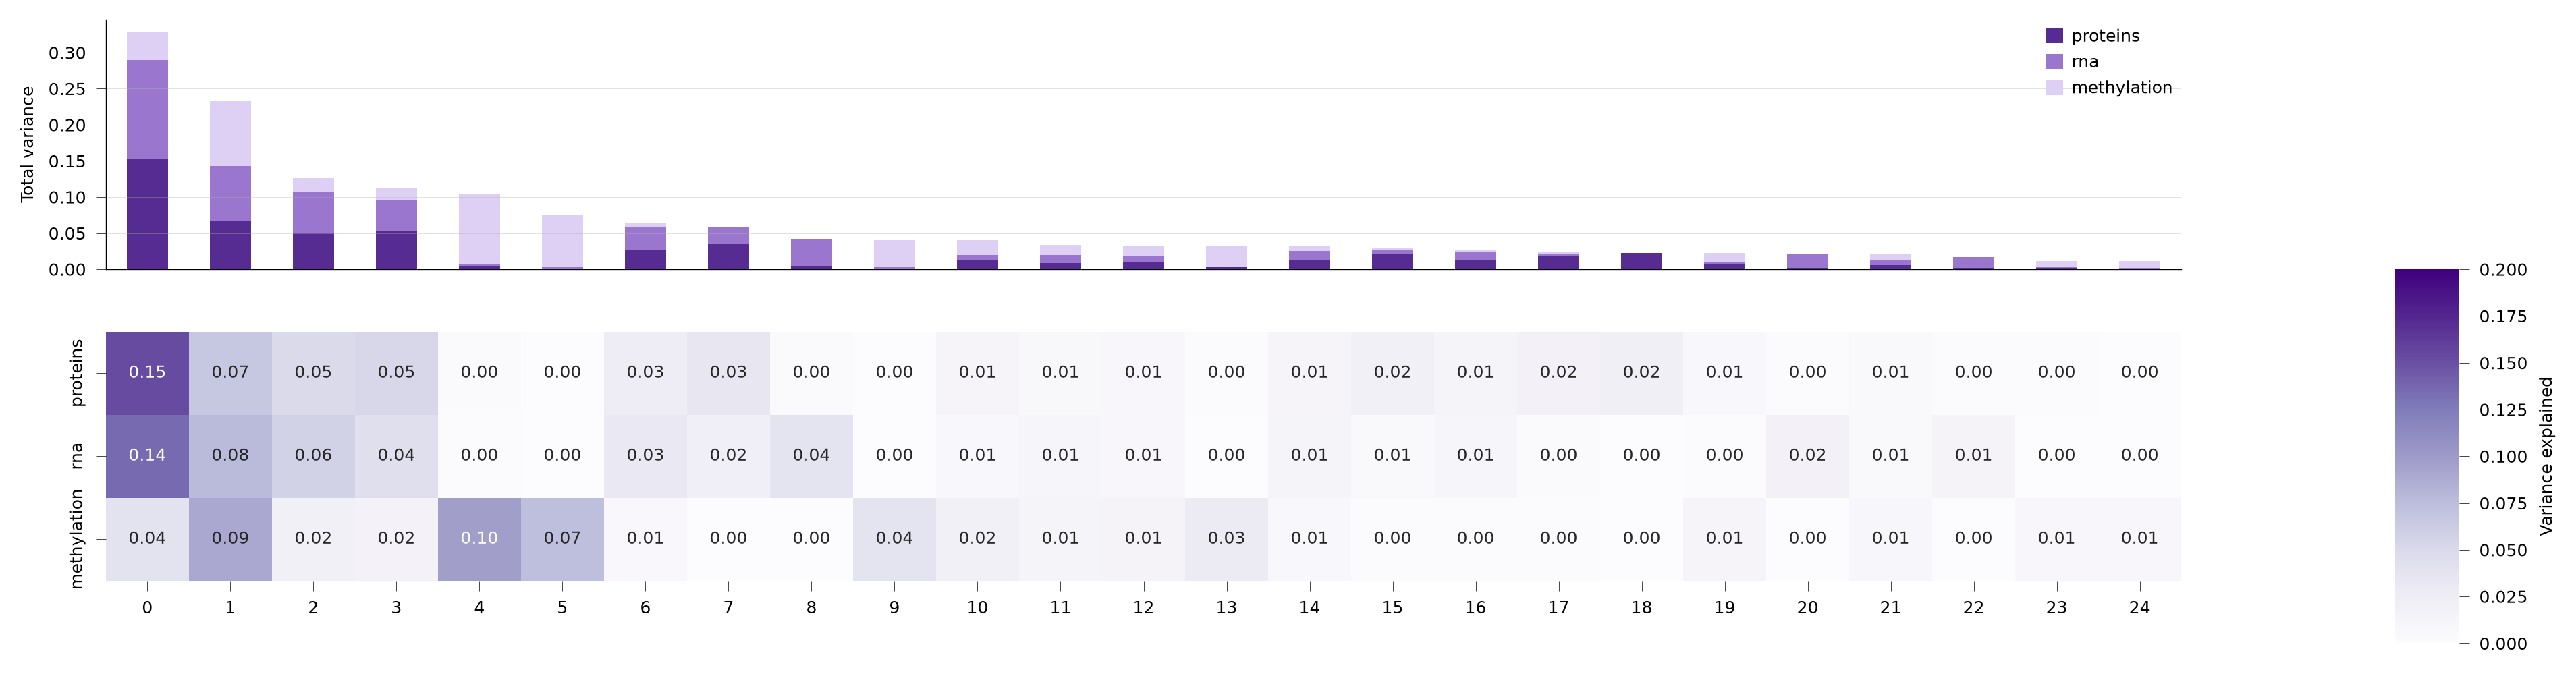

In [25]:
explained_variance = (
    pd.DataFrame.from_dict(mdata.uns["mofa"]["variance"], orient="index") / 100
)  # (MOFA+ reports in percent, we scale to floats)

fig, axs = plt.subplots(
    2,
    2,
    figsize=(15, 4),
    gridspec_kw={"height_ratios": [0.4, 0.6], "width_ratios": [0.97, 0.03], "hspace": 0},
    squeeze=True,
)

explained_variance.T.plot.bar(ax=axs[0, 0], color=["#572c92", "#9b76ce", "#decff4"], stacked=True)
axs[0, 0].set_xticks([])
axs[0, 0].set_yticks(np.arange(0, 0.31, 0.05), minor=True)
axs[0, 0].grid(axis="y", alpha=0.5, which="minor")
axs[0, 0].grid(axis="y", alpha=0.5, which="major")

axs[0, 0].spines[["top", "right"]].set_visible(False)
axs[0, 0].set_ylabel("Total variance")
axs[0, 1].set_axis_off()


sns.heatmap(
    explained_variance,
    square=True,
    annot=True,
    fmt=".2f",
    ax=axs[1, 0],
    cbar_ax=axs[1, 1],
    cbar_kws={"shrink": 0.1, "label": "Variance explained"},
    vmin=0,
    vmax=0.2,
    cmap="Purples",
)

plt.show()

We see that the first ~7 factors each explain more than 5% of variance. We can also see that some factors share variance across all modalities (most prominently factor 1), while in other cases, the explained variance is dominated by certain modalities. For example, factors 0, 2, and 3 are dominated by the RNA and Protein modalities, while factors 4 and 5 are only relevant for the methylation measurements.

### Factor activity analysis 

We can plot the MOFA+ embeddings similar to a PCA. Note that we plot the first and third components of the MOFA+ embedding, as the 2nd component does not capture variation aligned with histological differences:

... storing 'sex' as categorical
... storing 'previous_histology' as categorical
... storing 'who2015_histology' as categorical
... storing 'smokingstatus' as categorical
... storing 'smokingstatus_binary' as categorical


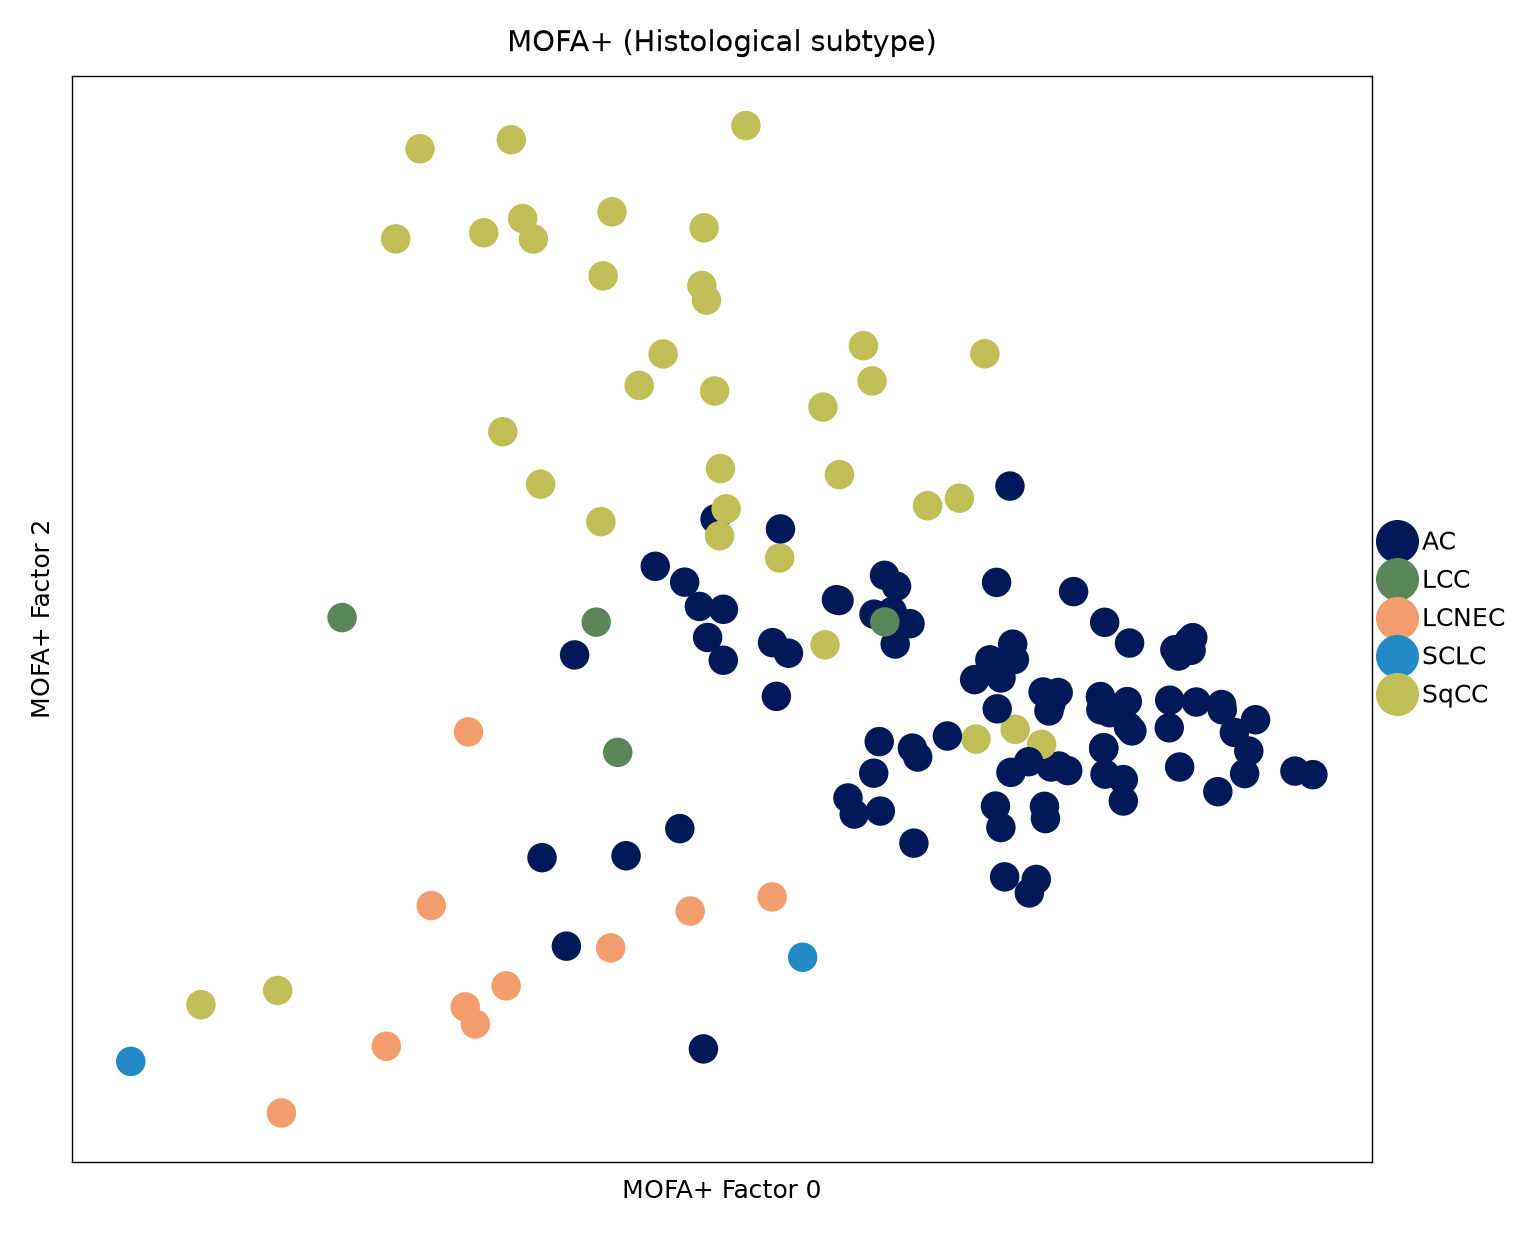

In [26]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(5, 4))

muon.pl.embedding(
    mdata,
    basis="X_mofa",
    color="who2015_histology",
    dimensions=(0, 2),
    palette=apt.pl.BasePalettes().get("qualitative"),
    size=200,
    ax=axm[0],
    title="",
    show=False,
)

apt.pl.label_axes(title="MOFA+ (Histological subtype)", xlabel="MOFA+ Factor 0", ylabel="MOFA+ Factor 2", ax=axm[0])

We see that factor 2 strongly separates the subtypes squamous cell carcinoma (SCC), adenocarcinoma (AC), and Large Cell Neuroendocrine Carcinoma (LCNEC). 

### Investigate factor loadings

In the following, we will investigate factor 2 of the MOFA+ model in more detail, given that it separates the 3 major histological subtypes in the cohort. For that, we first extract the MOFA+ - inferred gene weights per modality from the mudata object:

In [27]:
mdata = md.read_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")

In [28]:
mofa_loadings = pd.DataFrame(
    mdata.varm["LFs"], index=pd.MultiIndex.from_frame(mdata.var.reset_index(names="genes")[["genes", "modality"]])
)

mofa_loadings

,,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
genes,modality,,,,,,,,,,,,,,,,,,,,,
A1BG,proteins,0.164065,-0.048386,-0.003010,-0.097204,0.000207,0.000138,-0.016774,-1.303219e-01,-0.013422,0.000568,...,0.675114,-0.191230,0.020933,-1.093288,-0.042900,0.003749,0.027486,0.010059,-0.041027,0.002495
A2M,proteins,0.331158,-0.049883,0.036367,-0.267725,0.006633,0.001249,0.008056,-7.131368e-04,-0.015745,-0.001303,...,0.896177,0.006282,0.012406,-0.587029,-0.068040,0.016736,-0.011274,0.006011,-0.057393,0.003782
A2ML1,proteins,-0.153156,-0.134610,0.581281,-0.273981,0.001352,-0.000511,-0.216364,-4.800184e-02,0.000510,0.002371,...,-0.013399,0.017802,0.103392,-0.053368,0.016705,-0.016580,-0.121412,0.003679,0.002773,0.005852
A4GALT,proteins,-0.070697,0.119442,0.350132,-0.083855,0.018932,0.000480,-0.204056,-3.341188e-01,-0.006835,0.005221,...,0.011232,0.237233,0.490524,-1.636248,0.066438,-0.047599,0.300294,-0.021927,0.100616,-0.004536
AAAS,proteins,-0.227075,0.083270,-0.003178,0.031520,0.013970,0.001779,-0.006925,9.783037e-04,0.000481,-0.003083,...,-0.030744,-0.117929,-0.010597,-0.350677,0.055019,0.003402,-0.046622,0.039468,0.032885,0.000084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,methylation,0.000070,-0.000239,-0.010583,0.007343,-0.279440,0.002739,-0.000181,-2.730973e-04,-0.000356,0.012120,...,0.000036,-0.002143,0.004373,-0.000716,-0.000654,-0.010131,-0.001638,-0.000030,0.006019,-0.151938
ZYG11B,methylation,-0.003669,0.001602,0.001583,0.089473,-0.000385,-0.031376,0.000439,-1.980882e-04,-0.000407,-0.055190,...,0.005784,-0.001108,-0.003157,-0.000294,-0.001139,0.064775,-0.000319,0.000012,-0.036458,-0.004711
ZYX,methylation,0.000916,0.032057,-0.007839,0.009572,-1.891451,0.026408,0.010796,-2.353931e-07,-0.000270,-0.083291,...,0.001242,-0.005427,0.032167,-0.000303,-0.001075,0.010446,-0.013087,0.000009,-0.000782,-0.085215


In [29]:
mofa_loadings[[1]].nlargest(50, 1)
# mofa_loadings[[1]].nsmallest(50, 1)

,,1
genes,modality,
EVI2A,methylation,0.708216
CGN,rna,0.693291
CHML,methylation,0.690455
PTPRC,methylation,0.678661
P2RY12,methylation,0.664087
RAP1GAP,rna,0.660205
C5orf46,methylation,0.631396
KIAA1324,rna,0.629761
SLA2,methylation,0.627129


In [30]:
mofa_loadings.to_csv("../data/results/mofa-multimodal.loadings.tsv", sep="\t", index=True)

We can first investigate, which genes are particularly important for factor 2 by plotting the top gene weights in this factor:

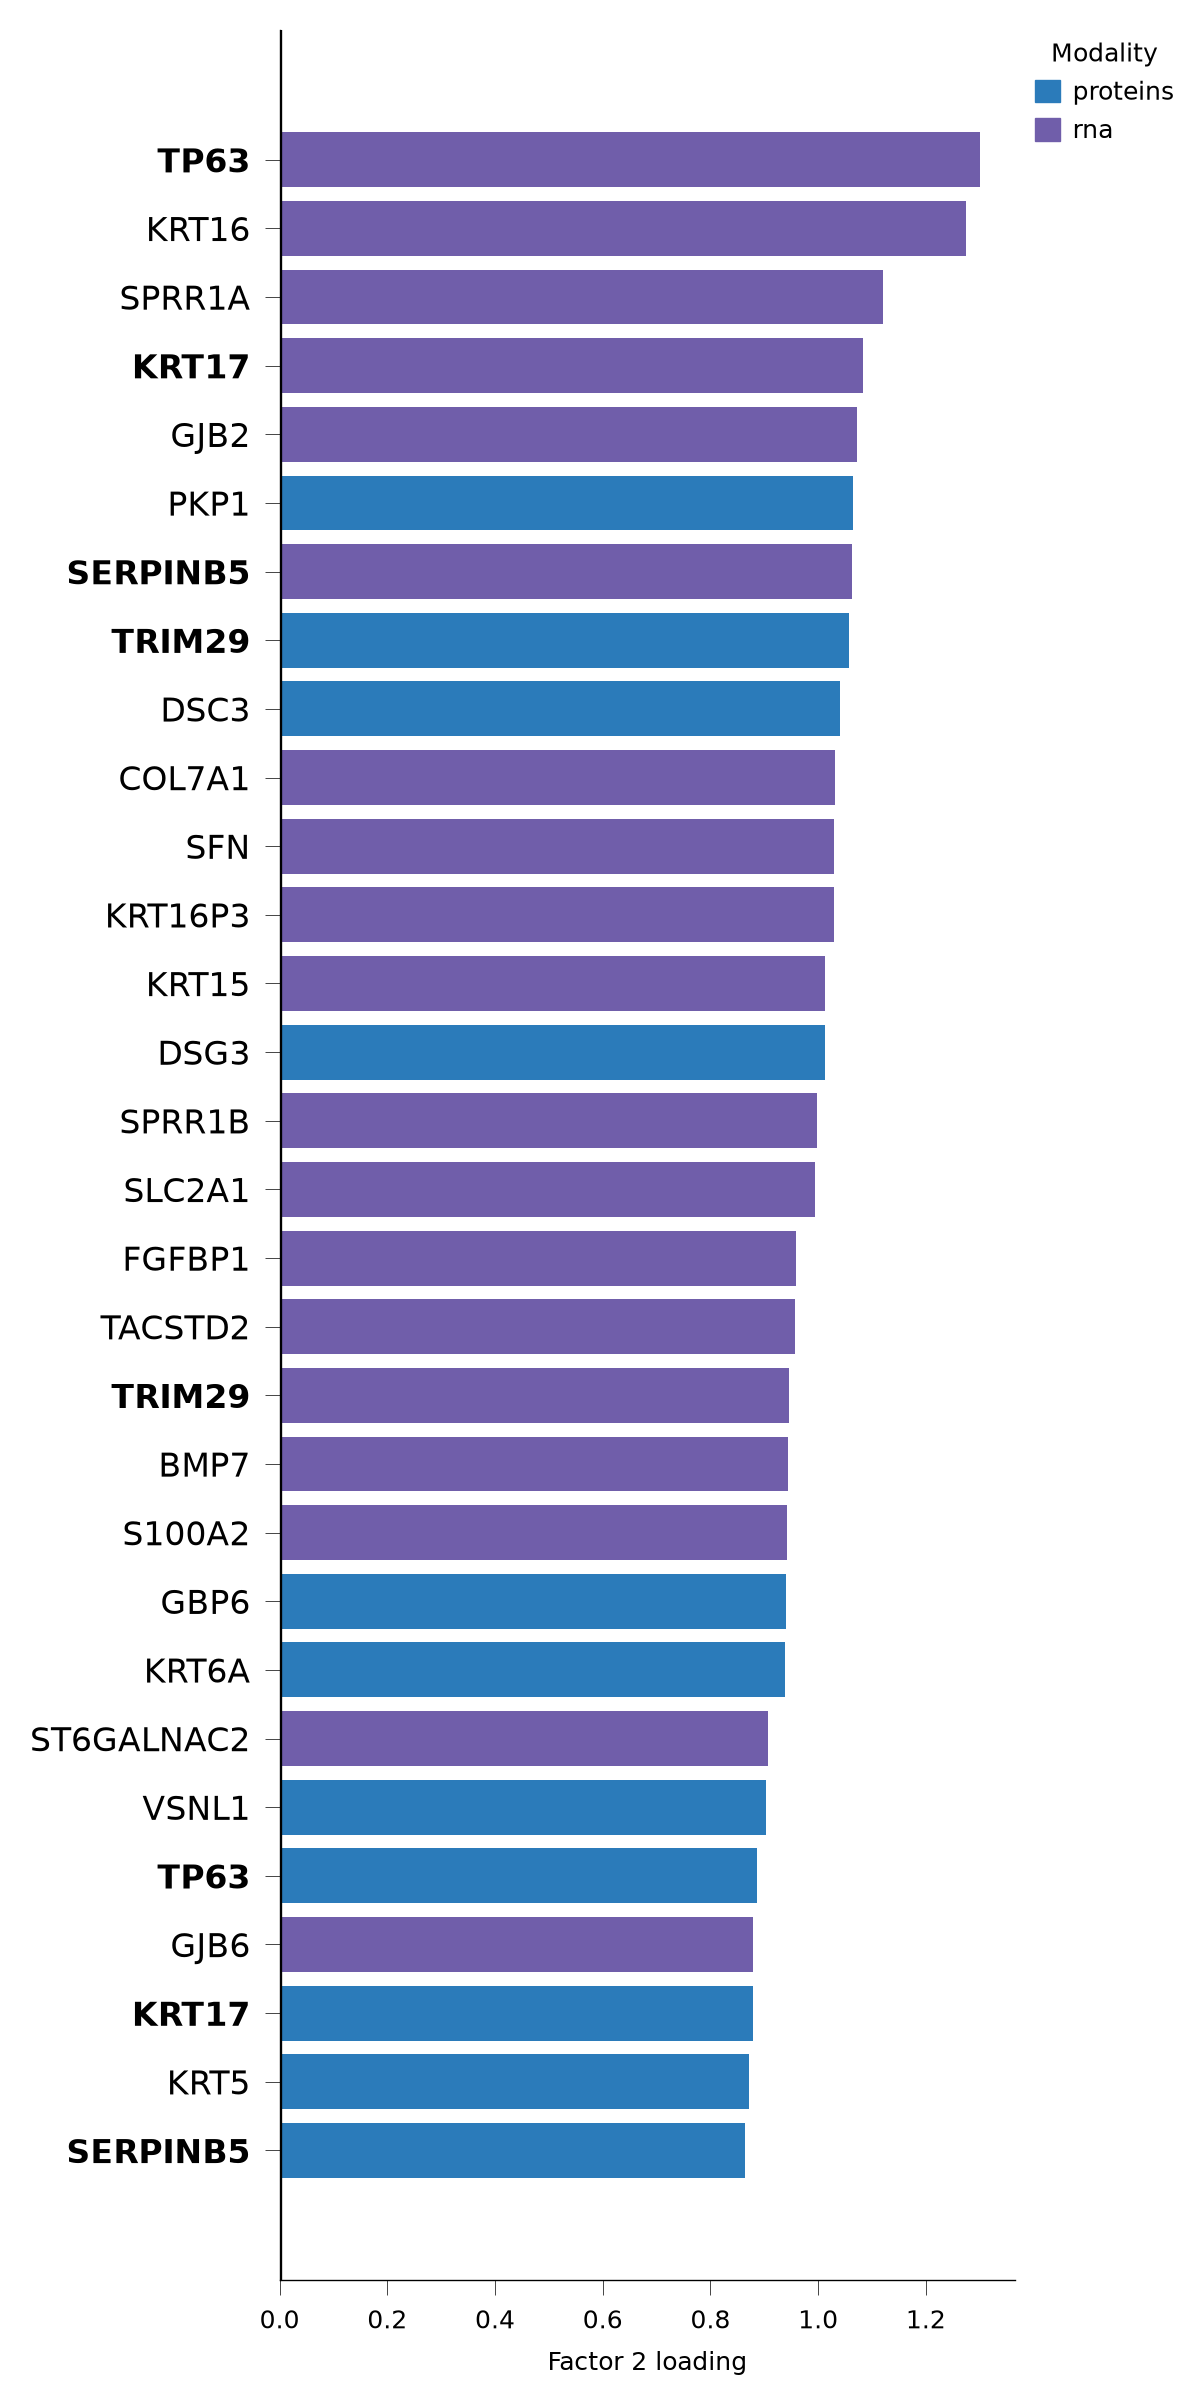

In [31]:
fig, ax = plt.subplots(figsize=(4, 8))

plot_modality_loadings(
    mofa_loadings.nlargest(30, 2).reset_index(),
    score=2,
    feature="genes",
    palette=palette,
    xlabel="Factor 2 loading",
    ax=ax,
)

plt.tight_layout()
plt.show()

Both RNA and protein features dominate the top loadings (features that are associated with high factor activity, i.e. Squamous Cell Carcinoma). Interestingly, the top loading is associated with TP63 (RNA; Rank 26 for TP63-protein), a commonly used immunohistochemistry marker for squamous cell carcinoma (e.g. [Rossi et al,2009](https://doi.org/10.1177/1066896909336178)). 

#### Functional annotation with decoupler.mt.gsea

Next, we will be run gene set enrichment analysis via the decoupler framework to functionally annotate the inferred factors. 

For that, we will first download the `hallmarks` geneset resource with decoupler and clean it up:

In [32]:
resource = dc.op.resource("MSigDB", organism="human")

Then, we run the gene set enrichment analysis on every modality separately:

In [33]:
PATHWAY_DATABASES = [
    "go_biological_process", 
    "reactome_pathways", 
    "hallmark"
    ]

for pathway_database in PATHWAY_DATABASES:

    network = (
        resource.loc[resource["collection"] == pathway_database]
        .drop_duplicates()
        # Decoupler expects the network as bipartite graph in which genesets (sources) point to genes (targets)
        .rename(columns={"genesymbol": "target", "geneset": "source"})
    )
    network.to_csv(f"../data/raw/{pathway_database}.network.tsv", sep="\t")

    results = []
    for mod, loadings in mofa_loadings.groupby("modality", observed=True):
        # Decoupler expects a (factor x genes) dataframe without duplicates
        decoupler_input = (
            loadings.reset_index(level="genes").drop_duplicates(subset="genes", keep=False).set_index("genes").T
        )
        scores, pvals = dc.mt.gsea(data=decoupler_input, net=network)

        # Generate a long dataframe that contains factor number, pathway, enrichment score, FDR, and indicator of modality
        results.append(
            pd.merge(  # noqa: PD015
                scores.melt(ignore_index=False, var_name="pathway", value_name="score").reset_index(names="factor"),
                pvals.melt(ignore_index=False, var_name="pathway", value_name="pval_adj").reset_index(names="factor"),
                on=["factor", "pathway"],
            ).assign(modality=mod)
        )

    # Concatenate results
    gsea_results = pd.concat(results, axis=0)
    gsea_results.to_csv(f"../data/results/gsea-results.{pathway_database}.tsv", sep="\t")

We now select which pathways to display. Two parameters control this:

- `FACTOR` — the MOFA+ factor whose loadings were tested for enrichment. We use factor `"2"`, as it separates the histological subtypes.
- `SIGNIFICANCE_THRESHOLD` — the largest adjusted p-value (FDR) a pathway may have to count as significant. We keep pathways at FDR ≤ 0.01.

We subset the enrichment results to the significant pathways of this factor and plot them:

In [34]:
# Parameters
FACTOR = "2"
SIGNIFICANCE_THRESHOLD = 1e-2

significant_pathways = gsea_results.loc[
    (gsea_results["factor"] == FACTOR) & (gsea_results["pval_adj"] <= SIGNIFICANCE_THRESHOLD)
].sort_values(by="score")

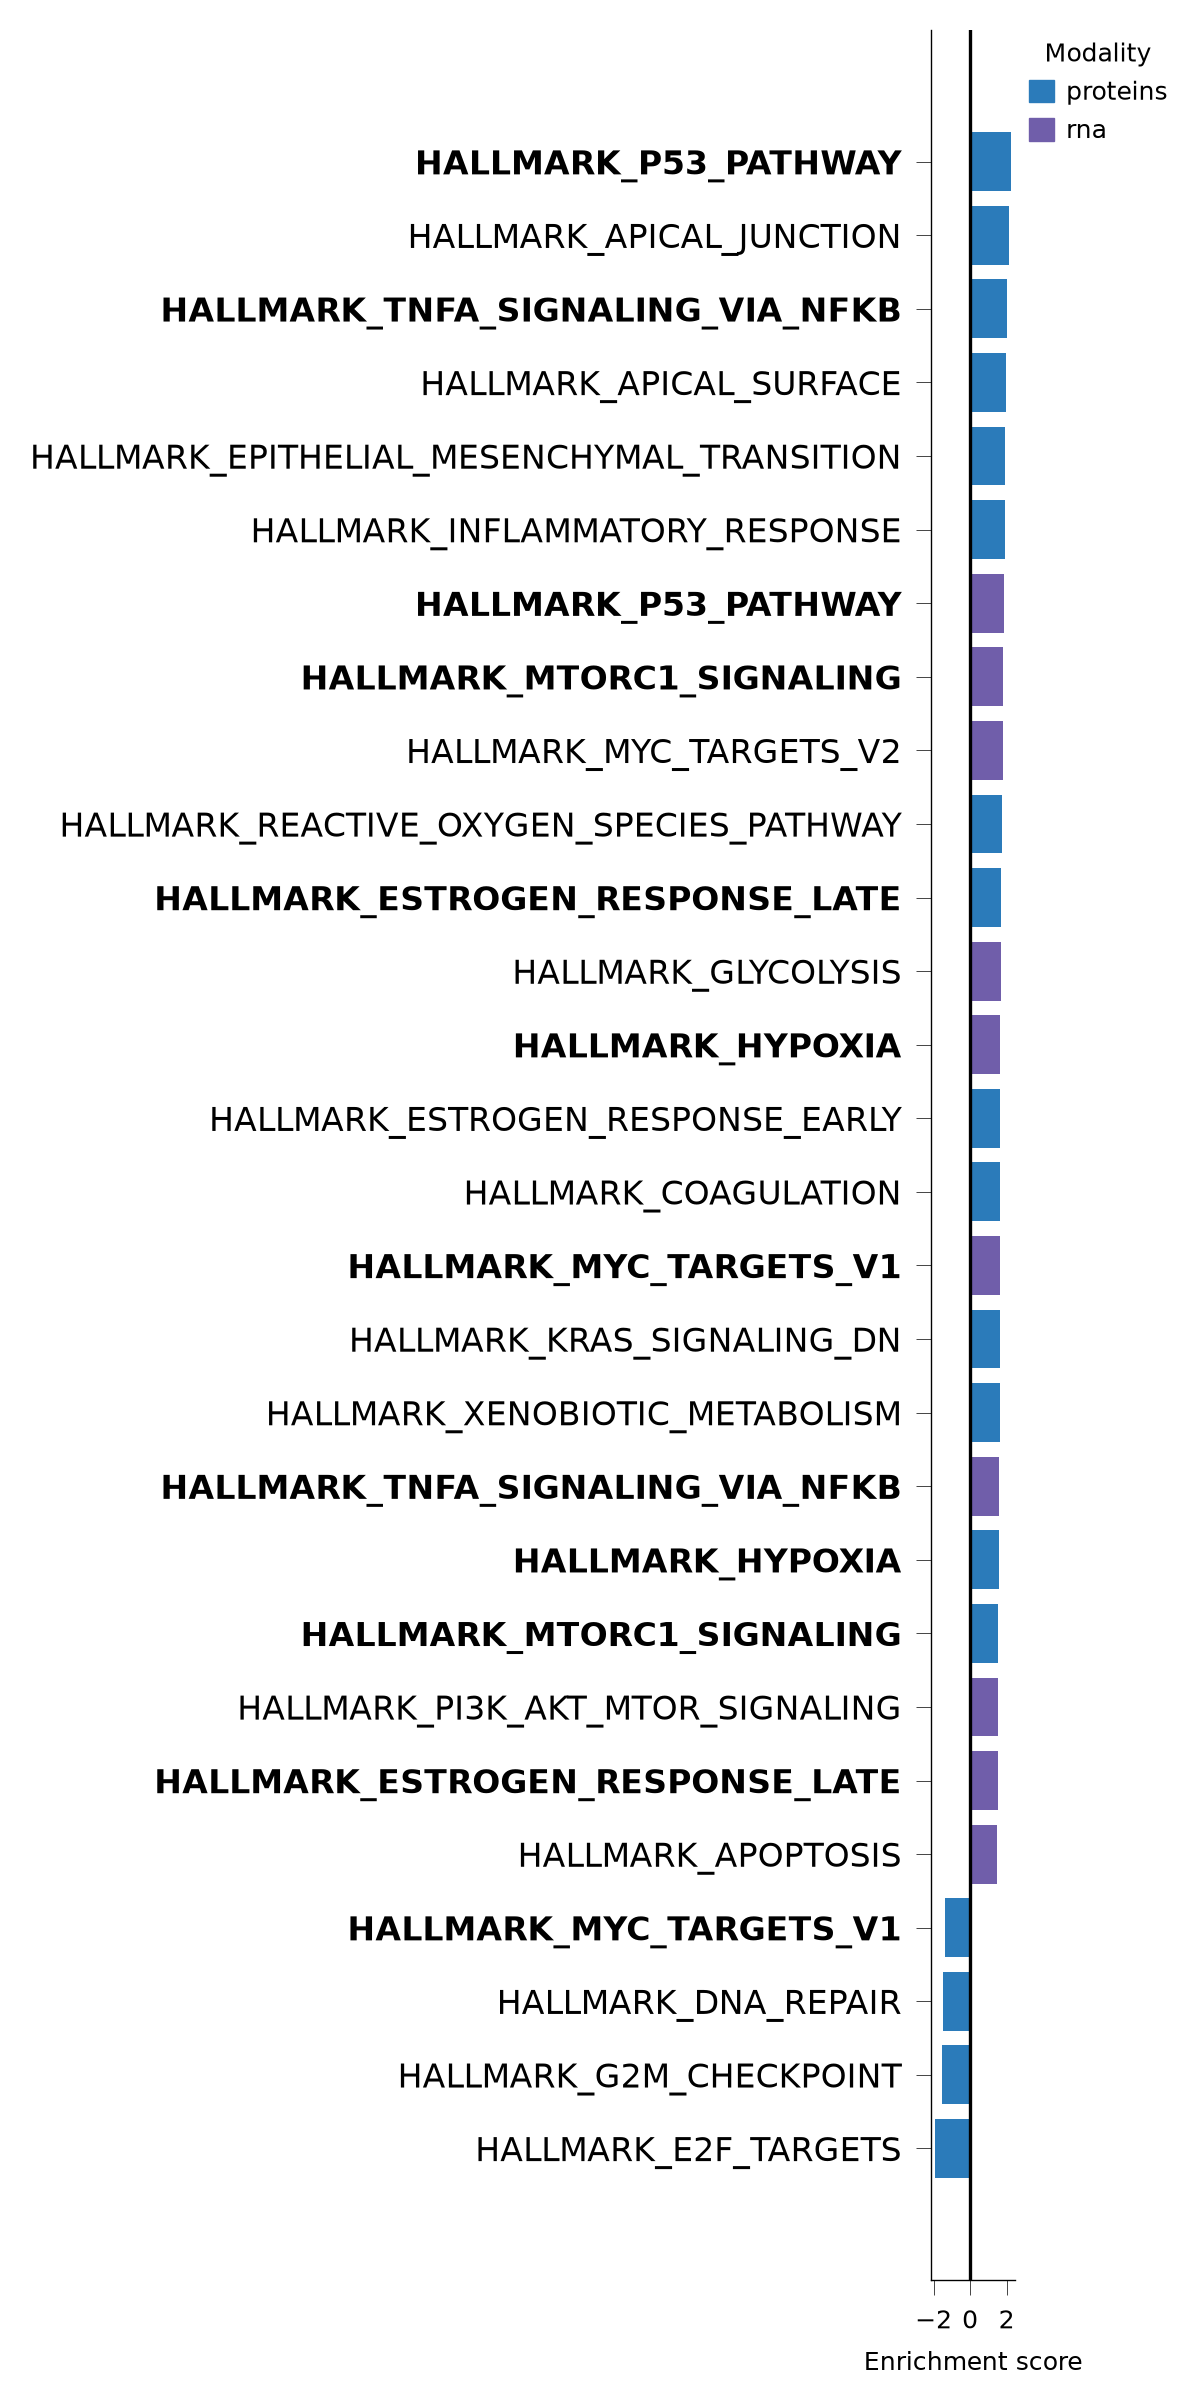

In [35]:
fig, ax = plt.subplots(figsize=(4, 8))

plot_modality_loadings(
    significant_pathways,
    score="score",
    feature="pathway",
    palette=palette,
    xlabel="Enrichment score",
    ax=ax,
)

plt.tight_layout()
plt.show()

Most pathways cluster around P53 and MYC signaling as well as metabolic pathways (mTORC1, glycolysis, etc.), as well as extracellular matrix remodeling. Interestingly, the p53 pathway is enriched in factor 2 at both the protein and the RNA expression level. We also see that many significantly enriched pathways are shared between protein and RNA levels, while others are distinct for the protein level (e.g. HALLMARK_ESTROGEN_RESPONSE_LATE). Overall, it is interesting to see that both modality-specific and joint processes can be observed in this factor.

### Separation of samples

We can check whether the joint modeling of proteomics, RNA, and methylation data improved the separation of samples based on their histological phenotype compared to _only_ the proteomics measurements. Here, we compute the _silhouette width_ of the histological subtypes on the MOFA+ embeddings for the multimodal modeling case and the proteomics-only modeling case, using the proteomics PCA embedding as a reference point.

The silhouette width ($s$) is a measure of how similar samples from the same condition are compared to samples from other conditions (separation). It ranges from −1 to +1, where higher values indicate better separation of conditions.

For comparison, we also compute principal components (PCA) and MOFA+ embedding for the single-modality measurements alone, using the same settings:

In [ ]:
# Run MOFA+
# Runs ca. 10 min on MacOS with M3
muon.tl.mofa(adata, **mofa_kwargs, outfile="../data/models/mofa-proteomics.model.hdf5")
muon.tl.mofa(rna, **mofa_kwargs, outfile="../data/models/mofa-rna.model.hdf5")
muon.tl.mofa(methylation, **mofa_kwargs, outfile="../data/models/mofa-methylation.model.hdf5")


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Scaling groups to unit variance...

Loaded view='data' group='group1' with N=141 samples and D=9793 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: True
- Spike-and-slab prior on the weights: True
Likelihood

We compute the silhouette width on the top factors / principal components of each embedding. The silhouette width is not well-behaved for very small groups, so we restrict the comparison to histological subtypes with more than 5 samples. This drops LCC (n=4) and SCLC (n=2), retaining AC, SqCC, and LCNEC. The results are qualitatively similar for other cutoffs.

In [37]:
# Minimum number of samples a histological subtype must have to be compared (rationale above)
MIN_GROUP_SIZE = 5

In [38]:
# Define embeddings per model
embeddings = {
    "Methylation (PCA)": (methylation.obsm["X_pca"], methylation.obs["who2015_histology"]),
    "RNA (PCA)": (
        rna.obsm["X_pca"],
        rna.obs["who2015_histology"],
    ),
    "Proteins (PCA)": (adata.obsm["X_pca_obs"], adata.obs["who2015_histology"]),
    "Methylation (MOFA+)": (methylation.obsm["X_mofa"], methylation.obs["who2015_histology"]),
    "RNA (MOFA+)": (
        rna.obsm["X_mofa"],
        rna.obs["who2015_histology"],
    ),
    "Proteins (MOFA+)": (adata.obsm["X_mofa"], adata.obs["who2015_histology"]),
    "Joint (MOFA+)": (mdata.obsm["X_mofa"], mdata.obs["who2015_histology"]),
}

# To make modalities with partially matched samples comparable, we subset to the intersection of samples
intersecting_samples = set.intersection(
    set(adata.obs_names.tolist()), set(rna.obs_names.tolist()), set(methylation.obs_names.tolist())
)

# We subset to groups with a sufficient number of samples
group_sizes = metadata.value_counts("who2015_histology")
kept_groups = group_sizes.index[group_sizes > MIN_GROUP_SIZE]

records = []
for method, (embedding, labels) in embeddings.items():
    keep = (labels.index.isin(intersecting_samples) & labels.isin(kept_groups)).tolist()
    kept_embedding, kept_labels = embedding[keep], labels[keep]

    records.append(
        {
            "method": method,
            "silhouette_width": silhouette_score(kept_embedding, labels=kept_labels, metric="euclidean"),
            "n_groups": kept_labels.nunique(),
        }
    )

silhouette_scores = pd.DataFrame.from_records(records)
silhouette_scores

,method,silhouette_width,n_groups
0,Methylation (PCA),0.079848,3
1,RNA (PCA),0.150960,3
2,Proteins (PCA),0.094554,3
3,Methylation (MOFA+),0.079161,3
4,RNA (MOFA+),0.136649,3
5,Proteins (MOFA+),0.112774,3
6,Joint (MOFA+),0.155610,3


... storing 'sex' as categorical
... storing 'previous_histology' as categorical
... storing 'who2015_histology' as categorical
... storing 'ac_mrna_subtype_tcga' as categorical
... storing 'sqcc_mrna_subtype_tcga' as categorical
... storing 'smokingstatus' as categorical
... storing 'smokingstatus_binary' as categorical
... storing 'stage_general' as categorical
... storing 'stage_detailed' as categorical
... storing 'adjuvant_therapy' as categorical
... storing 'sex' as categorical
... storing 'previous_histology' as categorical
... storing 'who2015_histology' as categorical
... storing 'ac_mrna_subtype_tcga' as categorical
... storing 'sqcc_mrna_subtype_tcga' as categorical
... storing 'smokingstatus' as categorical
... storing 'smokingstatus_binary' as categorical
... storing 'stage_general' as categorical
... storing 'stage_detailed' as categorical
... storing 'adjuvant_therapy' as categorical
... storing 'sex' as categorical
... storing 'previous_histology' as categorical
... sto

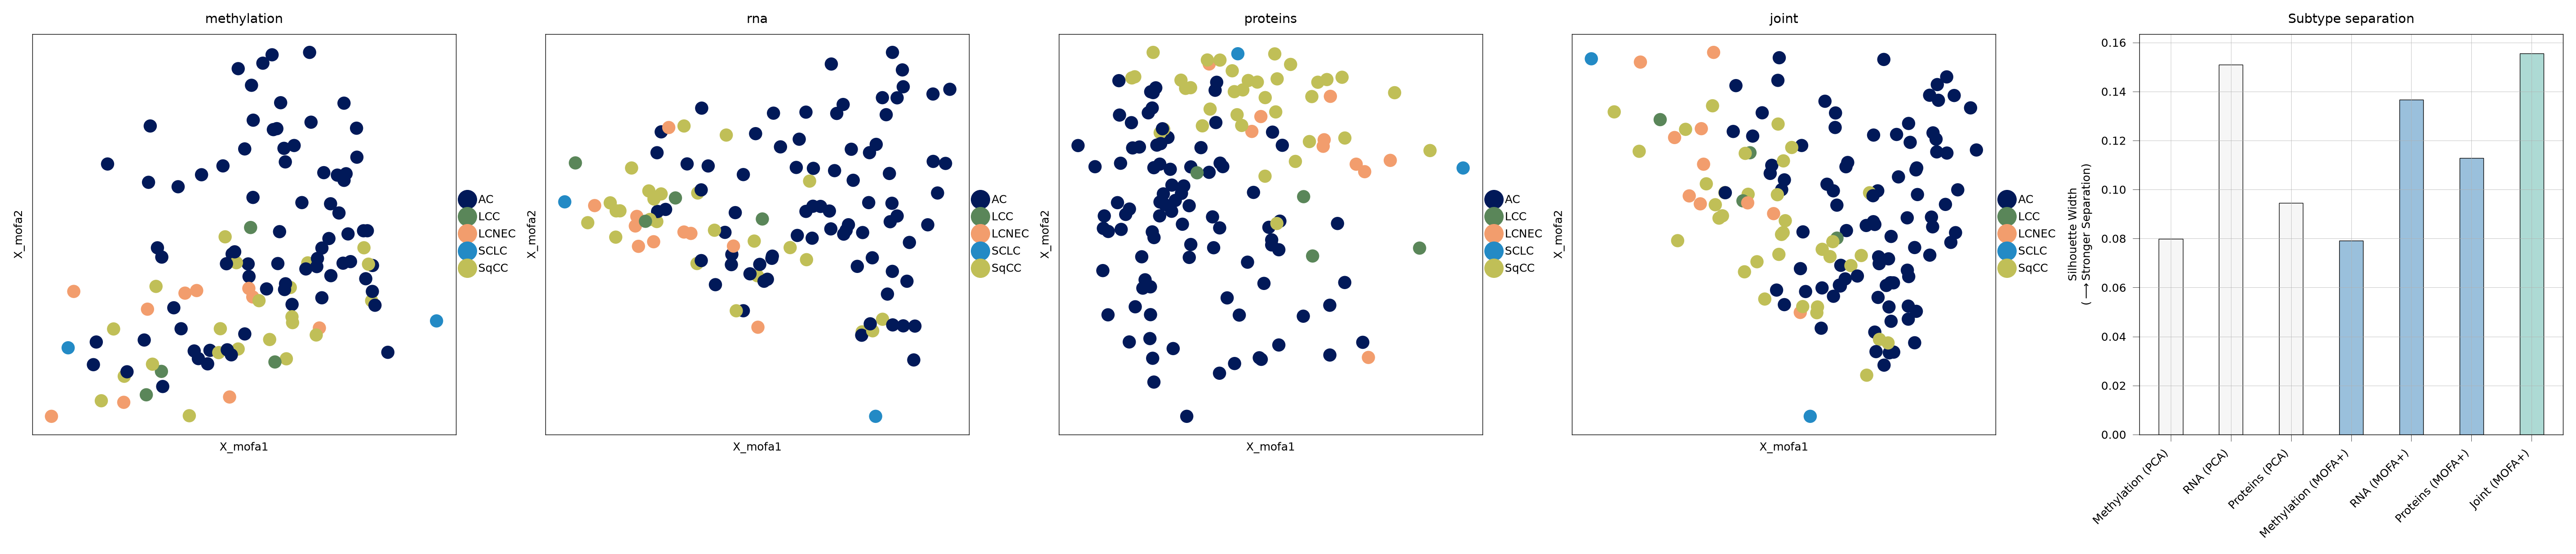

In [39]:
plot_kwargs = {
    "basis": "X_mofa",
    "color": "who2015_histology",
    "size": 200,
    "palette": apt.pl.BasePalettes().get("qualitative"),
    "show": False,
    "title": "",
}
modalities = {"methylation": methylation.copy(), "rna": rna.copy(), "proteins": adata.copy(), "joint": mdata.copy()}

fig, axm = apt.pl.create_figure(1, 5, figsize=(19, 4))

for idx, (modality, data) in enumerate(modalities.items()):
    muon.pl.embedding(data, ax=axm[idx], **plot_kwargs)
    apt.pl.label_axes(ax=axm[idx], title=modality)


apt.pl.barplot(
    ax=axm[4],
    data=silhouette_scores,
    value_column="silhouette_width",
    grouping_column="method",
    color_dict={
        "Methylation (PCA)": "#eeeeee",
        "RNA (PCA)": "#eeeeee",
        "Proteins (PCA)": "#eeeeee",
        "Methylation (MOFA+)": apt.pl.BaseColors.get("blue"),
        "RNA (MOFA+)": apt.pl.BaseColors.get("blue"),
        "Proteins (MOFA+)": apt.pl.BaseColors.get("blue"),
        "Joint (MOFA+)": apt.pl.BaseColors.get("green"),
    },
)
apt.pl.label_axes(
    ax=axm[4],
    ylabel="Silhouette Width\n($\\longrightarrow$Stronger Separation)",
    title="Subtype separation",
)
plt.xticks(rotation=45, ha="right")
plt.show()

The silhouette width analysis suggests that the joint modeling of the three available modalities improves the separation of histological subtypes **moderately** compared to the individual modalities.

That the integration of the multimodal data does not necessarily lead to a stronger separation of histological subtypes can have different reasons: 
1. Histology is a strong phenotype that is already well separated by each individual modality, so the separation might "top out" at a certain value, independent of the modality. 
2. As the original authors noted, there is additional molecular heterogeneity beyond the histological phenotype that cannot be resolved by the histological assessment, i.e. the labels we use do not recapitulate the full latent structure of the cohort.

## Summary

In this tutorial, we integrated MS-proteomics data with 2 complementary modalities. We jointly modeled them with a multi-factor model in the `muon` framework and biologically interpreted the resulting factors using `decoupler`. By representing MS-proteomics data as `anndata` objects, `alphapepttools` makes them directly interoperable with the scverse ecosystem and thus with complementary modalities.

In [40]:
mdata.write_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")
adata.write_h5ad("../data/pp/lehtio2021_nsclc_proteins.h5ad")
rna.write_h5ad("../data/pp/karlsson2014_nslc_rna.h5ad")
methylation.write_h5ad("../data/pp/karlsson2014_nslc_methylation.h5ad")

... storing 'sex' as categorical
... storing 'previous_histology' as categorical
... storing 'who2015_histology' as categorical
... storing 'ac_mrna_subtype_tcga' as categorical
... storing 'sqcc_mrna_subtype_tcga' as categorical
... storing 'smokingstatus' as categorical
... storing 'smokingstatus_binary' as categorical
... storing 'stage_general' as categorical
... storing 'stage_detailed' as categorical
... storing 'adjuvant_therapy' as categorical
... storing 'tmt_plex' as categorical
... storing 'tmt_channel' as categorical
... storing 'sex' as categorical
... storing 'previous_histology' as categorical
... storing 'who2015_histology' as categorical
... storing 'ac_mrna_subtype_tcga' as categorical
... storing 'sqcc_mrna_subtype_tcga' as categorical
... storing 'smokingstatus' as categorical
... storing 'smokingstatus_binary' as categorical
... storing 'stage_general' as categorical
... storing 'stage_detailed' as categorical
... storing 'adjuvant_therapy' as categorical
... stori

## Session Info 

In [41]:
from session_info2 import session_info

session_info()

Package,Version
pandas,3.0.5
alphapepttools,0.3.0
anndata,0.13.3.post0
decoupler,2.2.0
matplotlib,3.11.1
mudata,0.4.1
muon,0.1.9
numpy,2.5.3
scanpy,1.12.4
seaborn,0.13.2
